# Paracetamol Dosing Optimisation

This notebook builds a single-compartment pharmacokinetic (PK) model for oral paracetamol (acetaminophen), extends it to repeated dosing via superposition, and then searches over dose size and dosing interval to find the regimen that keeps plasma concentration within the therapeutic window for as long as possible over a 4-day period.

**Workflow:**
1. Define the single-dose Bateman PK model
2. Define clinically relevant concentration thresholds
3. Extend the model to repeated (multi-dose) administration
4. Define a scoring function that rewards staying in the therapeutic window
5. Grid-search over dose and interval to maximise the cumulative score (J-score)
6. Visualise the optimal dosing regimen

> **Disclaimer:** This is an educational modelling exercise using textbook population-average PK parameters. It is **not** medical advice and should not be used to guide real dosing decisions.


## 1. Pharmacokinetic Model

### The Bateman Equation (Single Oral Dose)

The plasma concentration of a drug over time $t$ following a single oral dose is expressed as:

$$C(t) = \frac{F \cdot D \cdot k_a}{V_d \cdot (k_a - k_e)} \left( e^{-k_e \cdot t} - e^{-k_a \cdot t} \right) , $$

$$V_d = V_{d,\text{norm}} \cdot \text{M}$$

Where:
* $\mathbf{C(t)}$: Plasma concentration at time $t$
* $\mathbf{D}$: Administered dose
* $\mathbf{F}$: Bioavailability fraction ($0 \le F \le 1$)
* $\mathbf{V_d}$: Volume of distribution
* $\mathbf{k_a}$: First-order absorption rate constant
* $\mathbf{k_e}$: First-order elimination rate constant
* $\mathbf{M}$: Mass of individual

The multiple constants can be represented as a single constant
$$U = \frac{F \cdot k_a}{V_d \cdot (k_a - k_e)}$$

This single-dose model is extended to repeated dosing in Section 4.


In [33]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
import math
from numpy import meshgrid


#Constants:
F = 0.8 #bioavailability
ke = math.log(2)/2.5 #elimination rate
ka = 2 #absorption rate
male_mass = 70 
female_mass = 50

male_or_female = input('Press M for Male or F for Female:').upper()
while True:
    if male_or_female == 'M':
        M = male_mass
        break
    elif male_or_female == 'F':
        M = female_mass
        break
    else:
        print('Pleasd Try Again!')
        male_or_female = input('Press M for Male or F for Female:')

volume_distribution_normalised = 0.9
V = volume_distribution_normalised * M 

#Replacing our constants with a single one U:
U = F*ka/(V*(ka-ke))

## 2. Threshold Definitions

| Symbol | Meaning |
|---|---|
| Max daily dose | Maximum oral paracetamol dose per day (mg/kg) |
| MEC | Minimum Effective Concentration — below this, the drug has no therapeutic effect |
| LBC | Lower Bound Concentration of the therapeutic window |
| UBC | Upper Bound Concentration of the therapeutic window |
| TOX | Toxic concentration threshold — above this, the drug becomes harmful |


In [34]:
#Thresholds:
maximum_daily_dose_per_kg = 150
maximum_daily_dose = maximum_daily_dose_per_kg * M
MEC = 5
LBC = 10
UBC = 20
TOX = 75 

## 3. Model Variables

We define three arrays that will be swept over the model:

* `dosage`: candidate single-dose amounts, from 0 mg up to the maximum daily dose, in 50 mg increments
* `time`: a 4-day timeline sampled every 5 minutes, used to evaluate plasma concentration
* `dosing_intervals`: candidate intervals between doses, from 1 to 24 hours (assuming a minimum of one dose per day)


In [35]:
dosage = np.arange(0,maximum_daily_dose,50) #goes up by 50mg each time
time = np.arange(0,(24*4),(1/12)) # 4 day timeline, with an time stamp every 5 mins
dosing_intervals = np.linspace(1,24,100) #100 time stamps between t=1hrs and h=24hrs (we assume a minimum of 1 pill a day)

## 4. Multi-Dose Concentration Function

During treatment, a patient takes multiple pills. We represent the resulting plasma concentration using the Principle of Superposition for linear, homogeneous ODEs, summing the contribution of every prior dose:

$$C(t) = UD \left[ \frac{e^{-k_e t}(1 - e^{(n+1)k_e\tau})}{1 - e^{k_e\tau}} - \frac{e^{-k_a t}(1 - e^{(n+1)k_a\tau})}{1 - e^{k_a\tau}} \right]$$

where $\tau$ is the dosing interval and $n$ is the number of doses already administered by time $t$.

The function below computes the concentration at any time, for any dosing interval and dose size:


In [36]:
def concentration_computation(t, tau,dose):
    constant = U*dose

    n = np.floor(t/tau)

    term1 = (np.exp(-ke * t) * (1 - np.exp((n+1) *ke * tau)))/(1 - np.exp(ke*tau))

    term2 = (np.exp(-ka * t) * (1 - np.exp((n+1) *ka * tau)))/(1 - np.exp(ka*tau))

    c_t = constant*(term1 - term2)
    c_t = np.maximum(np.nan_to_num(c_t ,posinf=0.0 ,neginf=0.0 , nan=0.0),0)
    return c_t

## 5. Objective (Scoring) Function

To evaluate a given regimen, we score each concentration value: no reward outside the therapeutic window, full reward inside it, and a linear ramp near the boundaries:

$$
S(C(t),\tau,D) = \begin{cases}
0 & \text{if } C(t) < \text{MEC} \text{ or } C(t) \ge \text{TOX} \\
\frac{C(t)-\text{MEC}}{\text{LBC}-\text{MEC}} & \text{if } \text{MEC} \le C(t) < \text{LBC} \\
1 & \text{if } \text{LBC} \le C(t) \le \text{UBC} \\
\frac{\text{TOX}-C(t)}{\text{TOX}-\text{UBC}} & \text{if } \text{UBC} < C(t) < \text{TOX}
\end{cases}
$$


In [37]:
# Lets remember that out input will be an array, so we can use numpy instead of a really long if-else statements
def score(conc):

    conditions = [(conc>=TOX) | (conc<MEC),
                  (conc>=LBC) & (conc<=UBC), 
                  (conc>=MEC) & (conc<=LBC),
                  (conc>=UBC) & (conc<TOX)
                  ]

    action = [0,
              1,
              (conc - MEC)/(LBC - MEC),
              (TOX - conc)/(TOX - UBC)
    ]

    score = np.select(conditions , action, 0)
    return score

## 6. J-Score Optimisation

Having built the concentration and scoring functions, we compute a **J-score** for every combination of dose and dosing interval. The J-score is the integral of the objective (scoring) function over the full 4-day period — i.e. the cumulative time-weighted reward for staying within the therapeutic window:

$$J = \int_{0}^{T} S(C(t), \tau, D) \, dt$$

Notes on the search:
- We build a 2D grid over `dosage` and `dosing_intervals`
- Regimens whose daily dose exceeds the maximum allowed daily dose are excluded
- `np.trapezoid()` gives a numerical (trapezoidal) approximation of the integral


In [38]:
J_grid = np.zeros((len(dosage) , len(dosing_intervals)))

for i , dose in enumerate(dosage):
    for j , interval in enumerate(dosing_intervals):
       
        N = np.floor(24/interval)
        daily_dose = N*dose

        if daily_dose > maximum_daily_dose:
            continue

        concentration_array = concentration_computation(time,interval,dose)
        score_array = score(concentration_array)

        J_grid[i][j] = np.trapezoid(score_array,time)

Interval between each dose: 3.3 hrs
Dosage: 1200 mg
Optimal J-Score: 95
Number of doses per day: 7


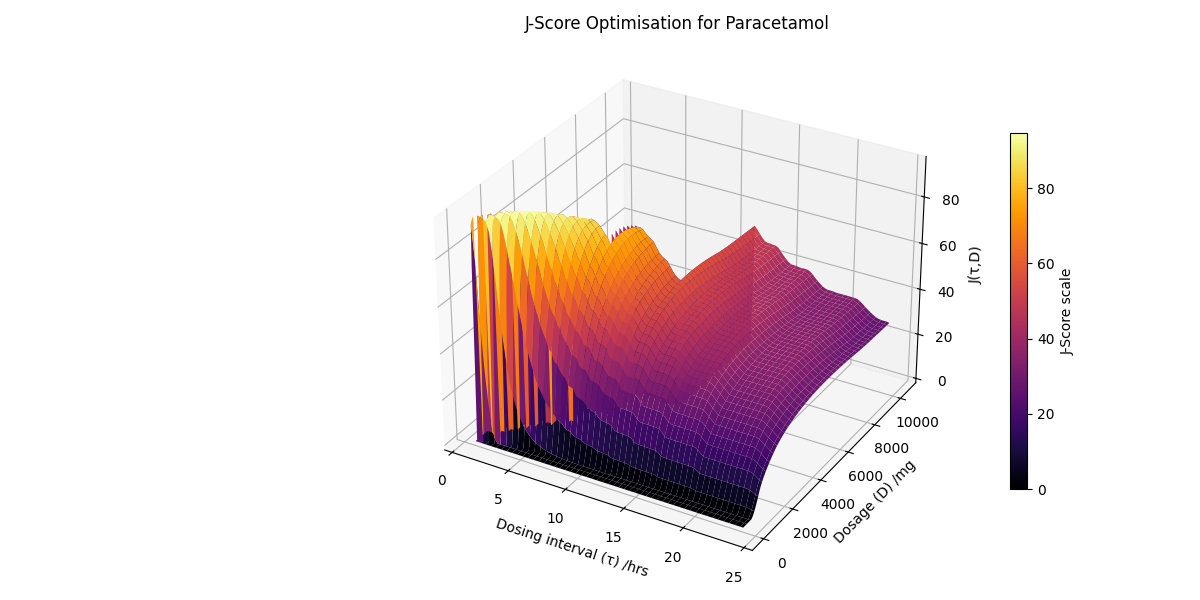

In [39]:
Interval_grid , Dosage_grid = np.meshgrid(dosing_intervals,dosage) 
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(projection='3d')
surface = ax.plot_surface(Interval_grid,Dosage_grid,J_grid, cmap='inferno')


plt.title('J-Score Optimisation for Paracetamol')
ax.set_xlabel('Dosing interval (τ) /hrs')
ax.set_ylabel('Dosage (D) /mg')
ax.set_zlabel('J(τ,D)')
fig.colorbar(surface,label = 'J-Score scale' , shrink = 0.65)

index = np.unravel_index(np.argmax(J_grid) , J_grid.shape)

max_x = Interval_grid[index]
max_y = Dosage_grid[index]
max_z = J_grid[index]


print(f'Interval between each dose: {max_x:.1f} hrs')
print(f'Dosage: {max_y} mg')
print(f'Optimal J-Score: {max_z:.0f}')

N_max = int(24/max_x)
print(f'Number of doses per day: {N_max}')
plt.tight_layout()
plt.show()

## 7. Results

Using the optimal dose and dosing interval identified above, we visualise the resulting plasma concentration over the full 4-day period. As expected, the concentration stays within the therapeutic window for the majority of the treatment course.


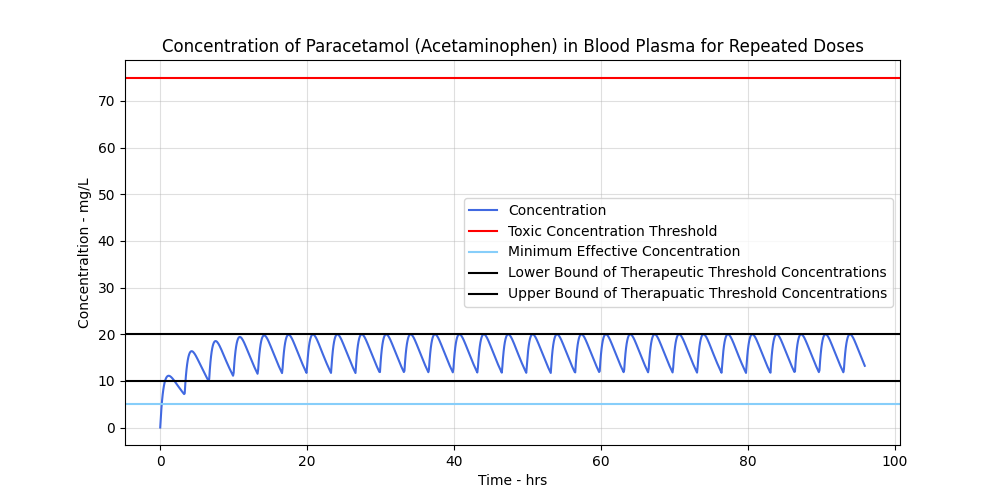

In [40]:
optimised_concentration = concentration_computation(time,max_x,max_y)

plt.figure(figsize=(10,5))
plt.plot(time,optimised_concentration, label='Concentration' , color = 'royalblue')

plt.axhline(TOX, color='red' , label='Toxic Concentration Threshold')
plt.axhline(MEC, color= 'lightskyblue' , label='Minimum Effective Concentration')
plt.axhline(UBC, color='black' , label = 'Lower Bound of Therapeutic Threshold Concentrations' )
plt.axhline(LBC, color='black' , label = 'Upper Bound of Therapuatic Threshold Concentrations' )

plt.xlabel('Time - hrs')
plt.ylabel('Concentraltion - mg/L')
plt.title('Concentration of Paracetamol (Acetaminophen) in Blood Plasma for Repeated Doses')

plt.legend()
plt.grid(True , alpha = 0.4)
plt.show()

## Limitations & Disclaimer

* **Population-average parameters:** $k_a$, $k_e$, and $V_{d,\text{norm}}$ are fixed textbook values, not individualised — real absorption/elimination rates vary with age, liver function, food intake, and formulation.
* **Single-compartment model:** this is a simplification of true multi-compartment drug distribution in the body.
* **Deterministic optimisation:** the grid search finds the best regimen *for this model*, not necessarily the safest or most effective one for a real patient.
* **Educational purposes only:** this notebook is a demonstration of PK modelling and numerical optimisation. It is **not** intended to inform real-world dosing decisions — always follow product labelling and consult a healthcare professional or pharmacist.
